In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.stats import hypergeom
from classes.SNPdataclass import SNPclass

In [2]:
file= "CRC_g4/intermediate/SNPdataAD.pkl"
#Load pickle file
with open(file, "rb") as file:
    data1 = pickle.load(file)
    print(data1)
data_matrix = data1.data
rsid_matrix = data1.rsid
chr_matrix = data1.chr
loc_matrix = data1.loc
pheno_matrix = data1.pheno
fid_matrix = data1.fid
pid_matrix = data1.pid
gender_matrix = data1.gender

In [3]:
print(data1)
#figure out which matrices to use for analysis. I will be using data, rsid and pheno
print(data_matrix.iloc[0:5])
print(rsid_matrix.iloc[0:5])
print(pheno_matrix.iloc[0:5])

   rs4970382_C  rs11260596_T  rs4072537_T  rs113355263_A  rs6603782_T  \
0          1.0           0.0          1.0            0.0          1.0   
1          1.0           1.0          1.0            0.0          0.0   
2          1.0           1.0          1.0            0.0          0.0   
3          1.0           0.0          0.0            0.0          1.0   
4          1.0           1.0          0.0            0.0          0.0   

   rs7518083_G  rs11523819_A  Affx-6162178_A  rs3107137_A  rs6686375_T  ...  \
0          1.0           1.0             1.0          0.0          1.0  ...   
1          1.0           1.0             1.0          1.0          1.0  ...   
2          1.0           1.0             1.0          0.0          0.0  ...   
3          1.0           1.0             0.0          1.0          1.0  ...   
4          0.0           0.0             0.0          0.0          1.0  ...   

   rs73891199_C  rs5771069_A  rs137888_A  rs8138121_C  rs11703226_C  \
0           0.0

In [4]:
#Define function to do hypergeometric test
def pairwise_hypergeom(df):
    results = []
    
    col1 = df['pheno'].values
    col2 = df['both'].values

    M = len(df)
    n = col1.sum()
    N = col2.sum()
    q = np.sum(col1 & col2)

    pval = 1 - hypergeom.cdf(q - 1, M, n, N)
    logpv = -np.log10(pval)

    results.append({
        'Group1': 'pheno',
        'Group2': 'both',
        'Overlap': int(q),
        'Group1_sig': int(n),
        'Group2_sig': int(N),
        'Total': M,
        'p-value': f"{pval:.3e}", 
        '-log10 p-value': logpv
        })

    return pd.DataFrame(results)

['11', '01', '10', '00']


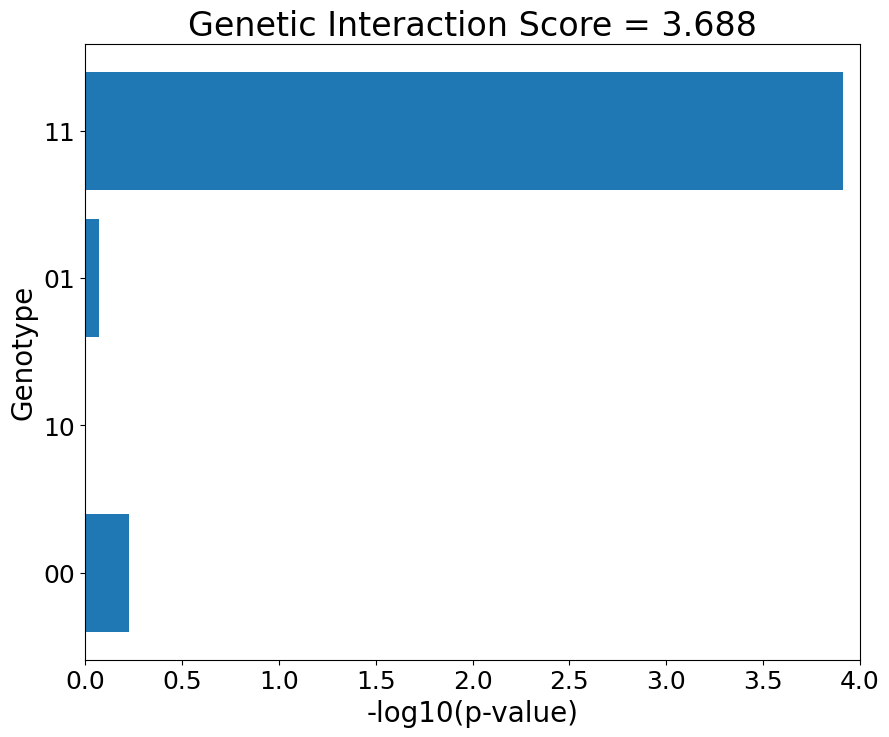

['11', '01', '10', '00']


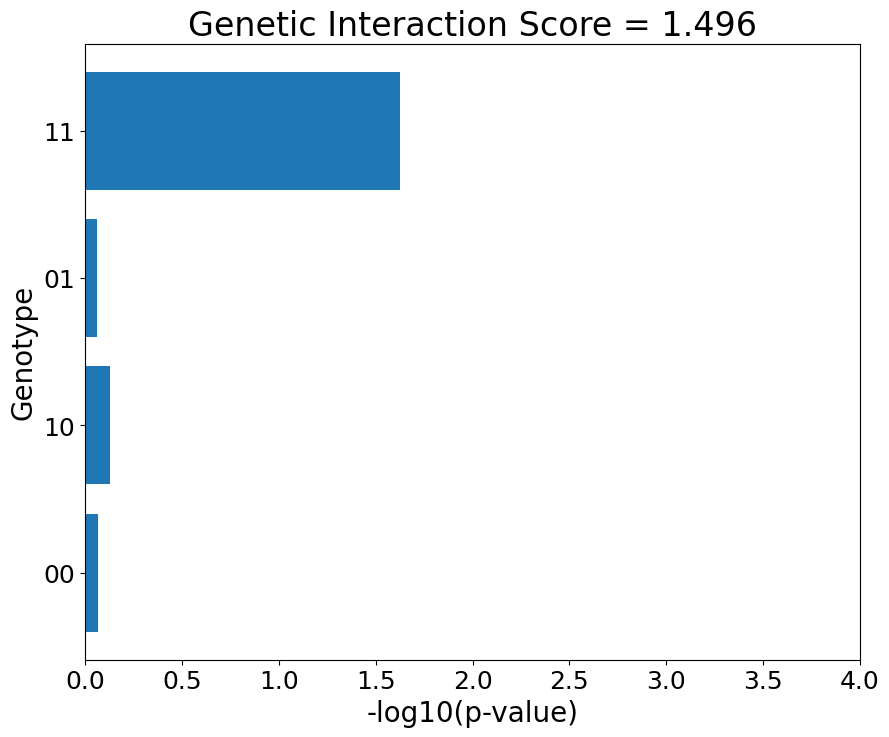

['11', '01', '10', '00']


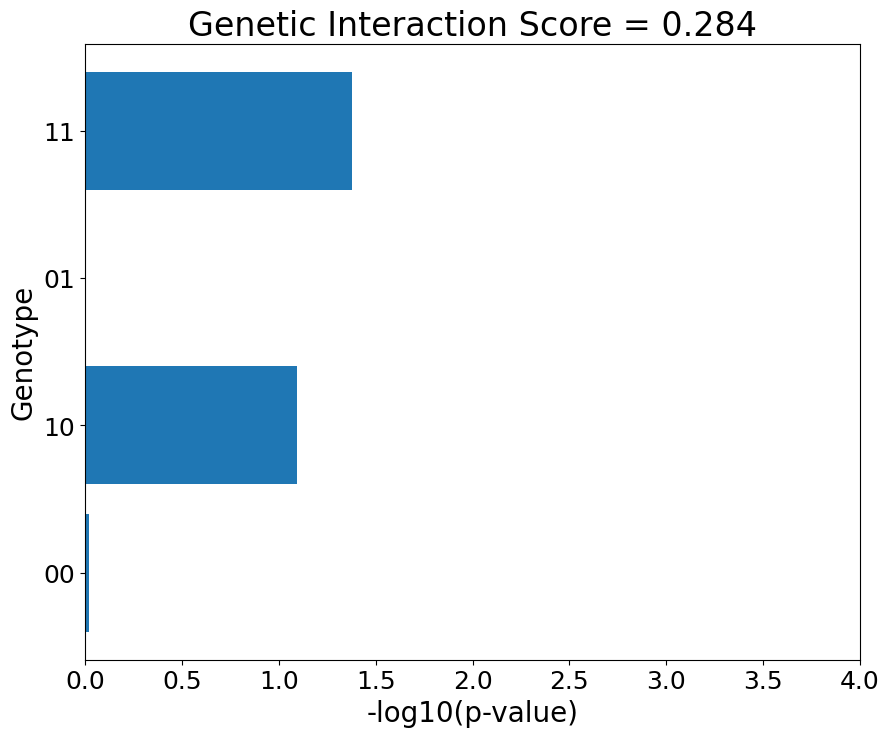

['11', '01', '10', '00']


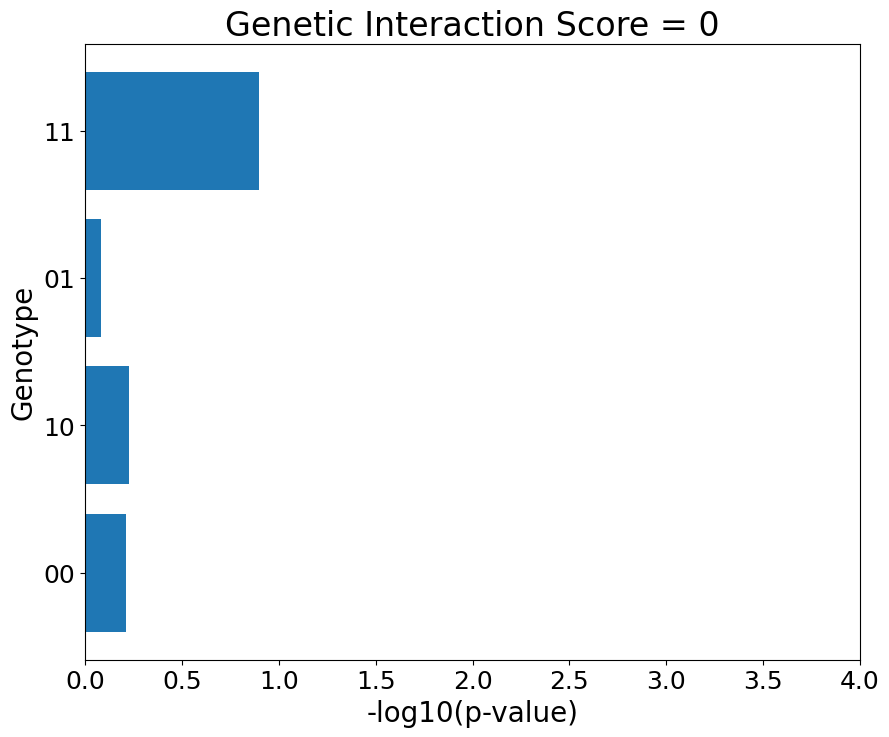

In [8]:
#Search for index of SNPs you want to look at. Third value in tuple is GI score
SNP_pair = [('rs2893343', 'rs7871088', 3.68761455650085), ('rs7768046', 'rs2247685',1.495968633), ('rs6018029','rs11042978',0.284271494), ('rs3813609', 'rs3117066', 0)]
for SNP in SNP_pair:
    #Find index of first SNP from rsid_matrix and then exract that column from data_matrix
    first_SNP = SNP[0]
    rsid_ind = rsid_matrix.loc[rsid_matrix == first_SNP].index
    first_col = data_matrix.iloc[:,rsid_ind]
    #Find index of second SNP from rsid_matrix and then extract that column from data_matrix
    second_SNP = SNP[1]
    rsid_ind2 = rsid_matrix.loc[rsid_matrix == second_SNP].index
    second_col = data_matrix.iloc[:,rsid_ind2]
    #Combine the dataframe together. Stitch the phenotype matrix onto it too
    combined_SNP = pd.concat([first_col,second_col,pheno_matrix], axis = 1)

    #Do a hypergeometric test on different disease models. Do it for dominant dominant first 1,1.
    #Determine how many rows contain 1 and 1 and binarize it accordingly. (ex. 1 and 1 = 1, 0 and 1 = 0)
    #Make an empty list to store results for different phenotypes
    results_dict = {}
    phenotypes = [(1,1), (0,1), (1,0), (0,0)]
    for i in phenotypes:
        binary_mask = (combined_SNP.iloc[:,0]==i[0]) & (combined_SNP.iloc[:,1]==i[1])
        combined_SNP['both'] = binary_mask.astype(int)
        #perform hypergeometric test
        results_df = pairwise_hypergeom(combined_SNP)
        #Add it to a results dictionary
        results_dict[i] = results_df.iloc[0,7]
    #Visualize it on a bar plot
    #Format data for this
    results_dict_keys = list(results_dict.keys())
    results_dict_vals = list(results_dict.values())
    #format the phenotypes for graphing
    new_pheno = [str(i[0])+str(i[1]) for i in results_dict_keys]
    print(new_pheno)
    plt.figure(figsize=(10, 8))
    plt.barh(new_pheno, results_dict_vals)
    plt.gca().invert_yaxis()
    plt.xlim(0, 4)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylabel('Genotype', fontsize=20)
    plt.xlabel('-log10(p-value)',fontsize=20)
    plt.title(f'Genetic Interaction Score = {round(SNP[2],3)}', fontsize=24)
    plt.savefig(f'GI_{round(SNP[2],3)}.png')
    plt.show()

In [129]:
print(results_dict)

{(1, 1): 3.9144109990591467, (0, 1): 0.07327282692425176, (1, 0): 0.00013145272235942065, (0, 0): 0.22679622121328488}


['11', '01', '10', '00']


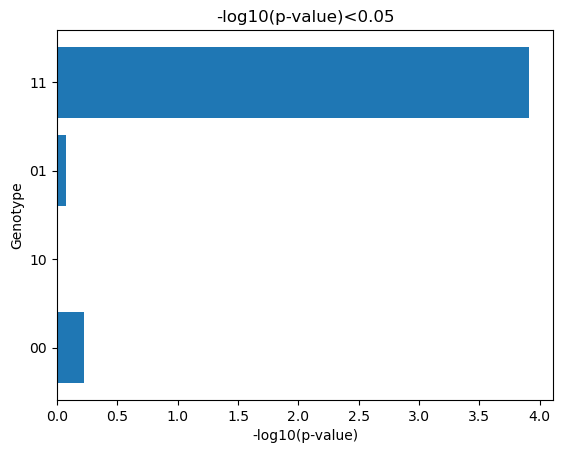

In [136]:
#Visualize it on a bar plot
#Format data for this
results_dict_keys = list(results_dict.keys())
results_dict_vals = list(results_dict.values())
#format the phenotypes for graphing
new_pheno = [str(i[0])+str(i[1]) for i in results_dict_keys]
print(new_pheno)
plt.barh(new_pheno, results_dict_vals)
plt.gca().invert_yaxis()
plt.ylabel('Genotype')
plt.xlabel('-log10(p-value)')
plt.title('-log10(p-value)<0.05')
#plt.savefig('Cancer_Types_ICD10.png')
plt.show()